# Tugas Besar DKA: Perbandingan Metode Fuzzy Mamdani dan Sugeno pada Sistem Rekomendasi Restoran (Scikit-Fuzzy Version)

**Mata Kuliah:** Dasar Komputasi Algoritma (DKA)  
**Topik:** Sistem Rekomendasi Restoran Berbasis Fuzzy Logic  
**Metode:** Fuzzy Mamdani vs Fuzzy Sugeno (Implementasi Berbasis Library Scikit-Fuzzy)

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from IPython.display import display
import time

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 1. Data Loading & Preprocessing (Dataset Real Zomato)

In [2]:
df = pd.read_csv('zomato.csv', encoding='latin-1')
print("Jumlah baris dan kolom dataset asli:", df.shape)

# Melakukan preprocessing data
cols = ['Restaurant Name', 'Average Cost for two', 'Price range',
        'Votes', 'Has Table booking', 'Has Online delivery', 'Aggregate rating']
data = df[cols].copy()

# Filter data: Hapus rating 0 & ubah kategorikal Yes/No menjadi numerik biner (1/0)
data = data[data['Aggregate rating'] > 0]
data['Has Table booking'] = data['Has Table booking'].map({'Yes': 1, 'No': 0})
data['Has Online delivery'] = data['Has Online delivery'].map({'Yes': 1, 'No': 0})
data = data.dropna().reset_index(drop=True)

print("Jumlah data setelah preprocessing siap pakai:", data.shape)
data.describe()

Jumlah baris dan kolom dataset asli: (9551, 21)
Jumlah data setelah preprocessing siap pakai: (7403, 7)


,Average Cost for two,Price range,Votes,Has Table booking,Has Online delivery,Aggregate rating
count,7403.000000,7403.000000,7403.000000,7403.000000,7403.000000,7403.000000
mean,1448.415102,1.970147,202.185060,0.150074,0.318114,3.440024
std,18303.524265,0.930611,479.195199,0.357168,0.465776,0.552195
min,0.000000,1.000000,4.000000,0.000000,0.000000,1.800000
25%,300.000000,1.000000,19.000000,0.000000,0.000000,3.000000
50%,500.000000,2.000000,60.000000,0.000000,0.000000,3.400000
75%,800.000000,3.000000,181.000000,0.000000,1.000000,3.800000
max,800000.000000,4.000000,10934.000000,1.000000,1.000000,4.900000


## 2. Inisialisasi Variabel Kontrol & Breakpoint (Sesuai Konsep Adaptif Modul)

In [3]:
max_cost = int(data['Average Cost for two'].max())
max_votes = int(data['Votes'].max())

def get_breakpoints(series):
    return {
        'min': series.min(),
        'p25': series.quantile(0.25),
        'p50': series.quantile(0.50),
        'p75': series.quantile(0.75),
        'max': series.max()
    }

bp_cost  = get_breakpoints(data['Average Cost for two'])
bp_votes = get_breakpoints(data['Votes'])

universe_cost = np.arange(0, max_cost + 10, 10)
universe_votes = np.arange(0, max_votes + 2, 1)
universe_price = np.arange(1, 6, 1)
universe_binary = np.arange(0, 2, 1)
universe_output = np.arange(0, 101, 1) 

harga = ctrl.Antecedent(universe_cost, 'harga')
votes = ctrl.Antecedent(universe_votes, 'votes')
price_range = ctrl.Antecedent(universe_price, 'price_range')
booking = ctrl.Antecedent(universe_binary, 'booking')
delivery = ctrl.Antecedent(universe_binary, 'delivery')

rekomendasi_mam = ctrl.Consequent(universe_output, 'rekomendasi_mam')

## 3. Pembuatan Fungsi Keanggotaan Segitiga & Trapesium (fuzz.trimf / fuzz.trapmf)

Fungsi keanggotaan kurva fuzzy berhasil dipetakan.


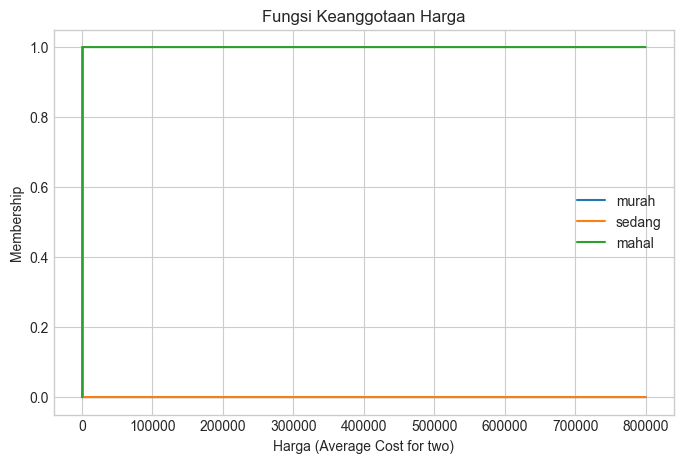

In [6]:
harga['murah'] = fuzz.trapmf(harga.universe, [bp_cost['min'], bp_cost['min'], bp_cost['p25'], bp_cost['p50']])
harga['sedang'] = fuzz.trimf(harga.universe, [bp_cost['p25'], bp_cost['p50'], bp_cost['p75']])
harga['mahal'] = fuzz.trapmf(harga.universe, [bp_cost['p50'], bp_cost['p75'], bp_cost['max'], bp_cost['max']])

votes['sedikit'] = fuzz.trapmf(votes.universe, [bp_votes['min'], bp_votes['min'], bp_votes['p25'], bp_votes['p50']])
votes['sedang'] = fuzz.trimf(votes.universe, [bp_votes['p25'], bp_votes['p50'], bp_votes['p75']])
votes['banyak'] = fuzz.trapmf(votes.universe, [bp_votes['p50'], bp_votes['p75'], bp_votes['max'], bp_votes['max']])

price_range['rendah'] = fuzz.trapmf(price_range.universe, [1, 1, 1, 2])
price_range['sedang'] = fuzz.trimf(price_range.universe, [1, 2, 3])
price_range['tinggi'] = fuzz.trapmf(price_range.universe, [2, 3, 4, 4])

for var in [booking, delivery]:
    var['tidak'] = fuzz.trimf(var.universe, [0, 0, 1])
    var['ya'] = fuzz.trimf(var.universe, [0, 1, 1])

rekomendasi_mam['tidak_layak'] = fuzz.trapmf(rekomendasi_mam.universe, [0, 0, 30, 50])
rekomendasi_mam['cukup_layak'] = fuzz.trimf(rekomendasi_mam.universe, [30, 50, 70])
rekomendasi_mam['sangat_layak'] = fuzz.trapmf(rekomendasi_mam.universe, [50, 70, 100, 100])

sugeno_const = {'tidak_layak': 20, 'cukup_layak': 50, 'sangat_layak': 85}

print("Fungsi keanggotaan kurva fuzzy berhasil dipetakan.")
plt.figure(figsize=(8, 5))
plt.plot(harga.universe, harga['murah'].mf, label='murah')
plt.plot(harga.universe, harga['sedang'].mf, label='sedang')
plt.plot(harga.universe, harga['mahal'].mf, label='mahal')
plt.title('Fungsi Keanggotaan Harga')
plt.xlabel('Harga (Average Cost for two)')
plt.ylabel('Membership')
plt.legend()
plt.show()

## 4. Penentuan 17 Aturan Fuzzy (Menggunakan Operator Bitwise skfuzzy `&` / `|`)

In [7]:
rules = [
    ctrl.Rule(harga['murah'] & votes['banyak'], rekomendasi_mam['sangat_layak']),
    ctrl.Rule(harga['murah'] & votes['sedang'], rekomendasi_mam['cukup_layak']),
    ctrl.Rule(harga['murah'] & votes['sedikit'], rekomendasi_mam['cukup_layak']),
    ctrl.Rule(harga['sedang'] & votes['banyak'], rekomendasi_mam['sangat_layak']),
    ctrl.Rule(harga['sedang'] & votes['sedang'], rekomendasi_mam['cukup_layak']),
    ctrl.Rule(harga['sedang'] & votes['sedikit'], rekomendasi_mam['tidak_layak']),
    ctrl.Rule(harga['mahal'] & votes['banyak'], rekomendasi_mam['cukup_layak']),
    ctrl.Rule(harga['mahal'] & votes['sedang'], rekomendasi_mam['tidak_layak']),
    ctrl.Rule(harga['mahal'] & votes['sedikit'], rekomendasi_mam['tidak_layak']),
    ctrl.Rule(price_range['rendah'] & votes['banyak'], rekomendasi_mam['sangat_layak']),
    ctrl.Rule(price_range['tinggi'] & votes['sedikit'], rekomendasi_mam['tidak_layak']),
    ctrl.Rule(price_range['sedang'] & votes['sedang'], rekomendasi_mam['cukup_layak']),
    ctrl.Rule(booking['ya'] & delivery['ya'], rekomendasi_mam['sangat_layak']),
    ctrl.Rule(booking['tidak'] & delivery['tidak'] & votes['sedikit'], rekomendasi_mam['tidak_layak']),
    ctrl.Rule(booking['ya'] & votes['sedang'], rekomendasi_mam['cukup_layak']),
    ctrl.Rule(delivery['ya'] & harga['murah'], rekomendasi_mam['sangat_layak']),
    ctrl.Rule(booking['tidak'] & harga['mahal'], rekomendasi_mam['tidak_layak'])
]

mamdani_ctrl = ctrl.ControlSystem(rules)
mamdani_sim = ctrl.ControlSystemSimulation(mamdani_ctrl)

print(f"Berhasil mengonstruksi {len(rules)} aturan logika ke dalam Control System.")

Berhasil mengonstruksi 17 aturan logika ke dalam Control System.


## 5. Mekanisme Inferensi Model Sugeno (Menggunakan Nilai Interp Skfuzzy)

In [14]:
def hitung_sugeno_skfuzzy(row):
    """
    Menghitung output Sugeno Orde-0 secara matematis dengan mengekstrak 
    derajat keanggotaan variabel langsung melalui fungsi interpolasi skfuzzy.
    """
    fz_harga = {k: fuzz.interp_membership(harga.universe, harga[k].mf, row['Average Cost for two']) for k in ['murah', 'sedang', 'mahal']}
    fz_votes = {k: fuzz.interp_membership(votes.universe, votes[k].mf, row['Votes']) for k in ['sedikit', 'sedang', 'banyak']}
    fz_price = {k: fuzz.interp_membership(price_range.universe, price_range[k].mf, row['Price range']) for k in ['rendah', 'sedang', 'tinggi']}
    fz_book  = {k: fuzz.interp_membership(booking.universe, booking[k].mf, row['Has Table booking']) for k in ['tidak', 'ya']}
    fz_deliv = {k: fuzz.interp_membership(delivery.universe, delivery[k].mf, row['Has Online delivery']) for k in ['tidak', 'ya']}
    
    alphas = [
        min(fz_harga['murah'], fz_votes['banyak']),
        min(fz_harga['murah'], fz_votes['sedang']),
        min(fz_harga['murah'], fz_votes['sedikit']),
        min(fz_harga['sedang'], fz_votes['banyak']),
        min(fz_harga['sedang'], fz_votes['sedang']),
        min(fz_harga['sedang'], fz_votes['sedikit']),
        min(fz_harga['mahal'], fz_votes['banyak']),
        min(fz_harga['mahal'], fz_votes['sedang']),
        min(fz_harga['mahal'], fz_votes['sedikit']),
        min(fz_price['rendah'], fz_votes['banyak']),
        min(fz_price['tinggi'], fz_votes['sedikit']),
        min(fz_price['sedang'], fz_votes['sedang']),
        min(fz_book['ya'], fz_deliv['ya']),
        min(fz_book['tidak'], fz_deliv['tidak'], fz_votes['sedikit']),
        min(fz_book['ya'], fz_votes['sedang']),
        min(fz_deliv['ya'], fz_harga['murah']),
        min(fz_book['tidak'], fz_harga['mahal'])
    ]
    
    labels = ['sangat_layak', 'cukup_layak', 'cukup_layak', 'sangat_layak', 'cukup_layak', 'tidak_layak',
              'cukup_layak', 'tidak_layak', 'tidak_layak', 'sangat_layak', 'tidak_layak', 'cukup_layak',
              'sangat_layak', 'tidak_layak', 'cukup_layak', 'sangat_layak', 'tidak_layak']
    
    num, den = 0.0, 0.0
    for alpha, label in zip(alphas, labels):
        num += alpha * sugeno_const[label]
        den += alpha
        
    return num / den if den != 0 else 50.0

## 6. Eksekusi Pengujian Sistem pada Seluruh Data & Komparasi Hasil MAE

In [9]:
mamdani_scores = []
sugeno_scores = []

print("Memulai perhitungan komputasi fuzzy pada seluruh baris dataset...")
start_time = time.time()

for idx, row in data.iterrows():
    mamdani_sim.input['harga'] = row['Average Cost for two']
    mamdani_sim.input['votes'] = row['Votes']
    mamdani_sim.input['price_range'] = row['Price range']
    mamdani_sim.input['booking'] = row['Has Table booking']
    mamdani_sim.input['delivery'] = row['Has Online delivery']
    
    try:
        mamdani_sim.compute()
        score_mam = mamdani_sim.output['rekomendasi_mam']
    except Exception:
        score_mam = 50.0 
        
    score_sug = hitung_sugeno_skfuzzy(row)
    
    mamdani_scores.append(score_mam)
    sugeno_scores.append(score_sug)

print(f"Pemrosesan selesai! Waktu eksekusi: {time.time() - start_time:.2f} detik.")

data['Mamdani_Score'] = mamdani_scores
data['Sugeno_Score'] = sugeno_scores
data['GroundTruth_Score'] = data['Aggregate rating'] * 20 

mae_mamdani = np.mean(np.abs(data['GroundTruth_Score'] - data['Mamdani_Score']))
mae_sugeno  = np.mean(np.abs(data['GroundTruth_Score'] - data['Sugeno_Score']))
rmse_mamdani = np.sqrt(np.mean((data['GroundTruth_Score'] - data['Mamdani_Score']) ** 2))
rmse_sugeno  = np.sqrt(np.mean((data['GroundTruth_Score'] - data['Sugeno_Score']) ** 2))

print("\n" + "="*40 + "\n  HASIL EVALUASI METRIK ERROR (BASED ON SKFUZZ)\n" + "="*40)
print(f"MAE  Model Mamdani : {mae_mamdani:.3f}")
print(f"MAE  Model Sugeno  : {mae_sugeno:.3f}")
print(f"RMSE Model Mamdani : {rmse_mamdani:.3f}")
print(f"RMSE Model Sugeno  : {rmse_sugeno:.3f}")

Memulai perhitungan komputasi fuzzy pada seluruh baris dataset...
Pemrosesan selesai! Waktu eksekusi: 204.51 detik.

  HASIL EVALUASI METRIK ERROR (BASED ON SKFUZZ)
MAE  Model Mamdani : 26.484
MAE  Model Sugeno  : 25.166
RMSE Model Mamdani : 30.828
RMSE Model Sugeno  : 29.308


## 7. Visualisasi Analisis Perbandingan Performa Model

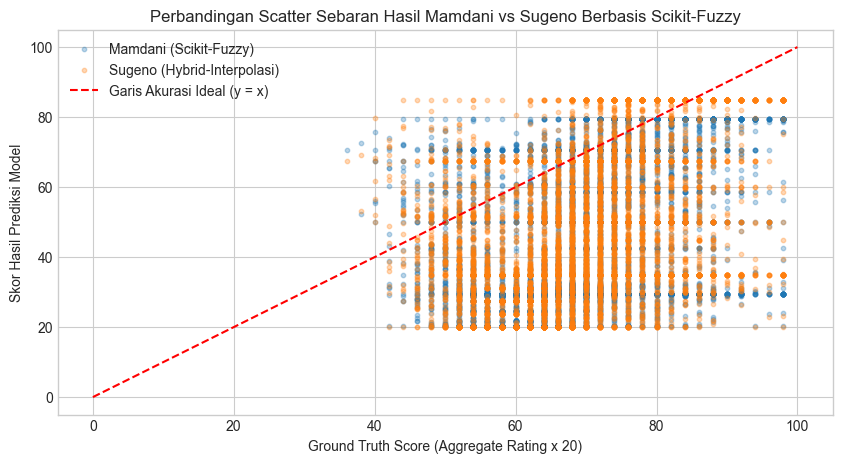

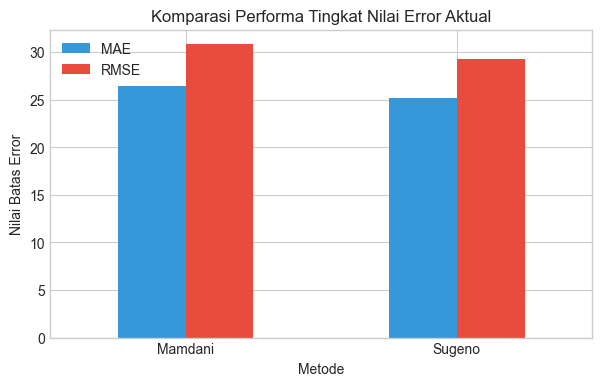

,Metode,MAE,RMSE
0,Mamdani,26.484304,30.827760
1,Sugeno,25.165864,29.307756


In [13]:
plt.figure(figsize=(10, 5))
plt.scatter(data['GroundTruth_Score'], data['Mamdani_Score'], alpha=0.3, label='Mamdani (Scikit-Fuzzy)', s=10)
plt.scatter(data['GroundTruth_Score'], data['Sugeno_Score'], alpha=0.3, label='Sugeno (Hybrid-Interpolasi)', s=10)
plt.plot([0, 100], [0, 100], 'r--', label='Garis Akurasi Ideal (y = x)')
plt.xlabel('Ground Truth Score (Aggregate Rating x 20)')
plt.ylabel('Skor Hasil Prediksi Model')
plt.title('Perbandingan Scatter Sebaran Hasil Mamdani vs Sugeno Berbasis Scikit-Fuzzy')
plt.legend()
plt.show()

metrics = pd.DataFrame({
    'Metode': ['Mamdani', 'Sugeno'],
    'MAE':  [mae_mamdani, mae_sugeno],
    'RMSE': [rmse_mamdani, rmse_sugeno]
})
metrics.set_index('Metode').plot(kind='bar', figsize=(7, 4), rot=0, color=['#3498db', '#e74c3c'])
plt.title('Komparasi Performa Tingkat Nilai Error Aktual')
plt.ylabel('Nilai Batas Error')
plt.show()

display(metrics)